# LD22 Moderate Precincts (Rep Positions 1 & 2)
Purpose: identify high-opportunity moderate precincts in LD22 for 2024. The incumbent reportedly won ~61% last cycle; we verify district baselines for both Representative positions (with candidate names) and use those to find precinct-level underperformance and compression.

Flow for the printed report:
1) Quick look at district results (2022 vs 2024) for **Rep Position 1 and Rep Position 2**, with candidate names + a clean chart.
2) Simple algorithm for "high-opportunity moderates": underperformance vs district, compression (no landslides), optional split-ticket.
3) Table + chart ranking precincts (Rep 1 and Rep 2 side by side for context).

## Data
- Source: `ld22_election_data.csv` (2022 midterm + 2024 presidential), includes registered voters and ballots cast.
- Baseline races: **Representative Position 1** and **Representative Position 2**.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.1f}".format
_df = pd.read_csv('ld22_election_data.csv')
print(f"Loaded {_df.shape[0]:,} rows")

Loaded 2,367 rows


## 1) District Results: 2022 vs 2024 (Rep Positions 1 & 2)

**Key context:**
- **2022**: Traditional D vs R races (Doglio vs Byrnes, Bateman vs Plager)
- **2024 Pos 1**: Beth Doglio (D) vs Steve Owens (Independent) — no Republican ran
- **2024 Pos 2**: Lisa Parshley (D) vs Syd Locke (D) — both Democrats (open seat)

In [18]:
# Build summary showing actual candidates (not just D vs R, since 2024 had D vs I and D vs D races)
TARGET_CONTESTS = ['Representative Position 1', 'Representative Position 2']

rows = []
for year in [2022, 2024]:
    for contest in TARGET_CONTESTS:
        tmp = _df[(_df['election_year'] == year) & (_df['contest'] == contest)]
        # Get top 2 candidates by votes (excludes write-ins usually)
        cand_totals = tmp.groupby(['candidate_name', 'party'])['votes'].sum().reset_index()
        cand_totals = cand_totals.sort_values('votes', ascending=False).head(2)
        
        if len(cand_totals) < 2:
            continue
            
        total_votes = cand_totals['votes'].sum()
        c1 = cand_totals.iloc[0]
        c2 = cand_totals.iloc[1]
        
        rows.append({
            'year': year,
            'contest': contest.replace('Representative ', 'Rep '),
            'candidate_1': f"{c1['candidate_name']} ({c1['party']})",
            'candidate_2': f"{c2['candidate_name']} ({c2['party']})",
            'cand1_pct': c1['votes'] / total_votes * 100,
            'cand2_pct': c2['votes'] / total_votes * 100,
            'total_votes': total_votes
        })

summary_df = pd.DataFrame(rows)
print("LD22 State House Results (2022 vs 2024)")
print("="*70)
print(summary_df[['year','contest','candidate_1','cand1_pct','candidate_2','cand2_pct']]
      .to_string(index=False))

LD22 State House Results (2022 vs 2024)
 year        contest         candidate_1  cand1_pct        candidate_2  cand2_pct
 2022 Rep Position 1     Beth Doglio (D)       65.9 Loretta Byrnes (R)       34.1
 2022 Rep Position 2 Jessica Bateman (D)       66.4    Kate Plager (R)       33.6
 2024 Rep Position 1     Beth Doglio (D)       70.0    Steve Owens (R)       30.0
 2024 Rep Position 2   Lisa Parshley (D)       64.2      Syd Locke (R)       35.8


### Chart: District results (easy to drop into Word)
Grouped bars for D and R by contest and year, with candidate names in labels and years on the x-axis.

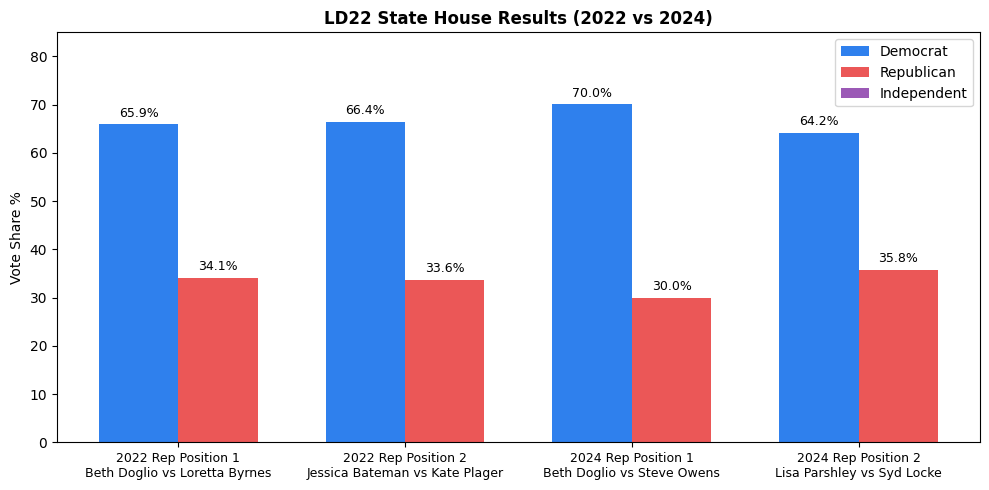


Note: 2024 Pos 1 was D vs Independent; 2024 Pos 2 was D vs D (open seat)


In [19]:
# Chart: Winner share by race (shows actual candidates, not misleading D vs R)
fig, ax = plt.subplots(figsize=(10, 5))

positions = np.arange(len(summary_df))
width = 0.35

# Color by actual party: D=blue, R=red, I=purple
def party_color(cand_str):
    if '(D)' in cand_str: return '#2f80ed'
    if '(R)' in cand_str: return '#eb5757'
    return '#9b59b6'  # Independent/other

colors1 = [party_color(c) for c in summary_df['candidate_1']]
colors2 = [party_color(c) for c in summary_df['candidate_2']]

ax.bar(positions - width/2, summary_df['cand1_pct'], width, color=colors1, label='Winner')
ax.bar(positions + width/2, summary_df['cand2_pct'], width, color=colors2, label='Runner-up')

# Labels on bars
for x, pct in zip(positions - width/2, summary_df['cand1_pct']):
    ax.text(x, pct + 1, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)
for x, pct in zip(positions + width/2, summary_df['cand2_pct']):
    ax.text(x, pct + 1, f"{pct:.1f}%", ha='center', va='bottom', fontsize=9)

# X-axis labels with candidate names
xtick_labels = [
    f"{int(r['year'])} {r['contest']}\n{r['candidate_1'].split(' (')[0]} vs {r['candidate_2'].split(' (')[0]}"
    for _, r in summary_df.iterrows()
]
ax.set_xticks(positions)
ax.set_xticklabels(xtick_labels, fontsize=9)
ax.set_ylabel('Vote Share %')
ax.set_title('LD22 State House Results (2022 vs 2024)', fontsize=12, fontweight='bold')
ax.set_ylim(0, 85)

# Custom legend for party colors
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2f80ed', label='Democrat'),
                   Patch(facecolor='#eb5757', label='Republican'),
                   Patch(facecolor='#9b59b6', label='Independent')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Note about 2024 races
print("\nNote: 2024 Pos 1 was D vs Independent; 2024 Pos 2 was D vs D (open seat)")

## 2) Algorithm: "high-opportunity moderate" precincts
Behavioral definition (no demographics):
- **Underperformance vs district baseline (core):** D and/or R share is below the 2024 district baselines for Rep 1 and Rep 2.
- **Vote-share compression:** No party clears 58% two-party share (avoid landslides).
- **Optional split-ticket:** Dem share range across Senator / Rep1 / Rep2 ? 4 pts signals candidate-level evaluation.

Scoring (simple, directional):
- Base = sum of negative gaps vs 2024 baselines across Rep 1 and Rep 2 (how far each party underperforms).
- +5 if compressed (no one clears 58% in either Rep 1 or Rep 2).
- +3 if split-ticket range ? 4.
Higher score = more moderate / persuadable.

## 3) Apply algorithm and rank precincts (includes both Rep 1 & Rep 2 for comparison)

In [20]:
import numpy as np
import pandas as pd

YEAR_A, YEAR_B = 2022, 2024
YEARS = [YEAR_A, YEAR_B]
CONTESTS = ["Representative Position 1", "Representative Position 2"]

df = _df.copy()

# Keep only LD22 + years + contests
df = df[
    (df["race_category"] == "Legislative District 22") &
    (df["election_year"].isin(YEARS)) &
    (df["contest"].isin(CONTESTS))
].copy()

# Sanity: totals row (if present)
df = df[df["precinct_name"].str.upper() != "COUNTY TOTALS"].copy()

# ----- 1) precinct/context fields (ballots/turnout) per year/precinct/contest -----
ctx = (df.groupby(["election_year","precinct_name","contest"], as_index=False)
         .agg(
             registered_voters=("registered_voters","max"),
             ballots_cast=("ballots_cast","max"),
             turnout_pct=("turnout_pct","max"),
             total_votes_in_race=("total_votes_in_race","max"),
         ))

# ----- 2) candidate totals per year/precinct/contest/candidate -----
cand = (df.groupby(["election_year","precinct_name","contest","candidate_name"], as_index=False)
          .agg(votes=("votes","sum"),
               total_votes_in_race=("total_votes_in_race","max")))

# Recompute share from votes/total to avoid trusting vote_share_pct
cand["share_pct"] = np.where(
    cand["total_votes_in_race"] > 0,
    (cand["votes"] / cand["total_votes_in_race"]) * 100,
    np.nan
).round(2)

# ----- 3) Pos 1: Doglio share swing (comparable 2022→2024) -----
DOGLO = "Beth Doglio"
pos1 = cand[cand["contest"] == "Representative Position 1"].copy()

doglio = pos1[pos1["candidate_name"] == DOGLO][
    ["election_year","precinct_name","share_pct"]
].rename(columns={"share_pct":"doglio_share_pct"})

doglio_w = (doglio.pivot_table(index="precinct_name", columns="election_year", values="doglio_share_pct")
                   .reset_index()
                   .rename(columns={YEAR_A:"doglio_2022", YEAR_B:"doglio_2024"}))

doglio_w["doglio_swing_pts"] = (doglio_w["doglio_2024"] - doglio_w["doglio_2022"]).round(2)

# ----- 4) Competitiveness: winner share + top-2 margin (works for ANY contest type) -----
# For each year/precinct/contest: get top2 shares
top2 = (cand.sort_values(["election_year","precinct_name","contest","votes"], ascending=[True,True,True,False])
           .groupby(["election_year","precinct_name","contest"], as_index=False)
           .head(2))

# rank 1 and 2
top2["rank"] = top2.groupby(["election_year","precinct_name","contest"])["votes"].rank(method="first", ascending=False)

winners = top2[top2["rank"] == 1][["election_year","precinct_name","contest","candidate_name","share_pct"]].rename(
    columns={"candidate_name":"winner_name","share_pct":"winner_share_pct"}
)
runners = top2[top2["rank"] == 2][["election_year","precinct_name","contest","candidate_name","share_pct"]].rename(
    columns={"candidate_name":"runnerup_name","share_pct":"runnerup_share_pct"}
)

comp = winners.merge(runners, on=["election_year","precinct_name","contest"], how="left")
comp["top2_margin_pts"] = (comp["winner_share_pct"] - comp["runnerup_share_pct"]).round(2)

# Pivot competitiveness to wide by contest
def short(contest):
    return contest.replace("Representative ", "Rep ").replace("Position ", "Pos ")

comp["contest_short"] = comp["contest"].apply(short)

comp_wide = (comp.pivot_table(
    index=["precinct_name","election_year"],
    columns="contest_short",
    values=["winner_share_pct","top2_margin_pts"]
))
comp_wide.columns = [f"{metric} | {contest}" for metric, contest in comp_wide.columns]
comp_wide = comp_wide.reset_index()

# Bring 2024 ballots/turnout for context (per contest)
ctx["contest_short"] = ctx["contest"].apply(short)
ctx_wide = (ctx.pivot_table(
    index=["precinct_name","election_year"],
    columns="contest_short",
    values=["ballots_cast","turnout_pct","total_votes_in_race"]
))
ctx_wide.columns = [f"{metric} | {contest}" for metric, contest in ctx_wide.columns]
ctx_wide = ctx_wide.reset_index()

# Merge all: context + competitiveness (both contests) + Doglio swing (Pos1)
out = (ctx_wide.merge(comp_wide, on=["precinct_name","election_year"], how="left"))

# Keep only 2022/2024 rows in a pivoted form for readability
out_w = (out.pivot_table(index="precinct_name", columns="election_year", aggfunc="first")
            .reset_index())

# Flatten columns
out_w.columns = [
    f"{a} ({b})" if b != "" else a
    for a,b in out_w.columns.to_flat_index()
]

# Merge Doglio swing table (one row per precinct)
final = out_w.merge(doglio_w, left_on="precinct_name", right_on="precinct_name", how="left")

# Candidate-readable sort keys (descriptive)
# Example: show biggest Doglio declines first
final = final.sort_values("doglio_swing_pts", ascending=True).reset_index(drop=True)

display(final)


,precinct_name,ballots_cast | Rep Pos 1 (2022),ballots_cast | Rep Pos 1 (2024),ballots_cast | Rep Pos 2 (2022),ballots_cast | Rep Pos 2 (2024),top2_margin_pts | Rep Pos 1 (2022),top2_margin_pts | Rep Pos 1 (2024),top2_margin_pts | Rep Pos 2 (2022),top2_margin_pts | Rep Pos 2 (2024),total_votes_in_race | Rep Pos 1 (2022),...,turnout_pct | Rep Pos 1 (2024),turnout_pct | Rep Pos 2 (2022),turnout_pct | Rep Pos 2 (2024),winner_share_pct | Rep Pos 1 (2022),winner_share_pct | Rep Pos 1 (2024),winner_share_pct | Rep Pos 2 (2022),winner_share_pct | Rep Pos 2 (2024),doglio_2022,doglio_2024,doglio_swing_pts
0,COLLEGE 129,107.0,169.0,107.0,169.0,79.4,65.5,80.6,4.1,102.0,...,79.7,46.9,79.7,89.2,82.4,90.3,51.7,89.2,82.4,-6.8
1,OLYMPIA #44 244,243.0,300.0,243.0,300.0,88.3,76.8,86.0,8.7,240.0,...,84.8,71.0,84.8,94.2,88.0,93.0,53.5,94.2,88.0,-6.1
2,LACEY #20 320,173.0,228.0,173.0,228.0,33.1,22.7,33.3,21.8,169.0,...,77.5,58.8,77.5,66.3,61.1,66.1,59.2,66.3,61.1,-5.2
3,LONG LAKE 075,141.0,156.0,141.0,156.0,24.6,17.9,23.9,36.7,138.0,...,88.6,78.8,88.6,62.3,58.6,61.9,66.4,62.3,58.6,-3.8
4,LACEY #42 342,126.0,231.0,126.0,231.0,35.8,28.8,31.2,24.9,123.0,...,58.2,31.6,58.2,67.5,64.1,65.6,61.3,67.5,64.1,-3.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154,LACEY #47 347,"1,120.0","1,167.0","1,120.0","1,167.0",23.5,48.9,25.4,59.5,"1,106.0",...,97.2,93.3,97.2,61.8,74.3,62.7,79.1,61.8,74.3,12.5
155,GLENWOOD 084,185.0,NaN,185.0,NaN,11.1,NaN,9.5,NaN,180.0,...,NaN,73.4,NaN,55.6,NaN,54.8,NaN,55.6,NaN,NaN
156,OLYMPIA #61 261,NaN,90.0,NaN,90.0,NaN,70.7,NaN,46.9,NaN,...,94.7,NaN,94.7,NaN,85.4,NaN,72.8,NaN,85.4,NaN
157,SIMMONS #3 069,18.0,NaN,18.0,NaN,41.2,NaN,41.2,NaN,17.0,...,NaN,62.1,NaN,70.6,NaN,70.6,NaN,29.4,NaN,NaN


In [21]:
# ---- helper: pick a column if it exists ----
def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# ---- helper: band labels (readable, ASCII-safe) ----
def margin_band(m):
    if pd.isna(m): return ""
    m = float(m)
    if m <= 10:  return "Very close (<=10 pts)"
    if m <= 20:  return "Close (10-20 pts)"
    if m <= 35:  return "One-sided (20-35 pts)"
    return "Landslide (>35 pts)"

def swing_band(s):
    if pd.isna(s): return ""
    s = float(s)
    if s <= -5:   return "Down 5+ pts"
    if s <= -2:   return "Down 2-5 pts"
    if s <  2:    return "Flat (+/-2 pts)"
    if s <  5:    return "Up 2-5 pts"
    return "Up 5+ pts"

# ---- resolve column names from your `final` table ----
df = final.copy()

prec_col = pick_col(df, ["Precinct", "precinct_name"])
dog22 = pick_col(df, ["doglio_2022"])
dog24 = pick_col(df, ["doglio_2024"])
dogswing = pick_col(df, ["doglio_swing_pts"])

b24_pos1 = pick_col(df, ["ballots_cast | Rep Pos 1 (2024)", "ballots_cast | Rep Pos 1 (2024.0)"])
t24_pos1 = pick_col(df, ["turnout_pct | Rep Pos 1 (2024)", "turnout_pct | Rep Pos 1 (2024.0)"])

m24_pos1 = pick_col(df, ["top2_margin_pts | Rep Pos 1 (2024)"])
m24_pos2 = pick_col(df, ["top2_margin_pts | Rep Pos 2 (2024)"])
w24_pos1 = pick_col(df, ["winner_share_pct | Rep Pos 1 (2024)"])
w24_pos2 = pick_col(df, ["winner_share_pct | Rep Pos 2 (2024)"])

missing = [n for n,v in {
    "Precinct": prec_col, "doglio_2022": dog22, "doglio_2024": dog24, "doglio_swing_pts": dogswing,
    "ballots_cast Pos1 2024": b24_pos1, "turnout Pos1 2024": t24_pos1,
    "margin Pos1 2024": m24_pos1, "margin Pos2 2024": m24_pos2,
    "winner share Pos1 2024": w24_pos1, "winner share Pos2 2024": w24_pos2,
}.items() if v is None]

if missing:
    raise ValueError(f"Expected columns not found in `final`: {missing}\n\nAvailable columns:\n{list(df.columns)}")

# ---- build candidate-facing view ----
candidate_view = pd.DataFrame({
    "Precinct": df[prec_col],
    "Ballots (2024)": df[b24_pos1],
    "Turnout % (2024)": df[t24_pos1].round(1),

    "Pos 1 winner share (2024)": df[w24_pos1].round(1),
    "Pos 1 margin (2024 pts)": df[m24_pos1].round(1),
    "Pos 1 closeness band": df[m24_pos1].apply(margin_band),

    "Pos 2 winner share (2024)": df[w24_pos2].round(1),
    "Pos 2 margin (2024 pts)": df[m24_pos2].round(1),
    "Pos 2 closeness band": df[m24_pos2].apply(margin_band),

    "Doglio share 2022 (Pos 1)": df[dog22].round(1),
    "Doglio share 2024 (Pos 1)": df[dog24].round(1),
    "Doglio change (pts)": df[dogswing].round(1),
    "Doglio change band": df[dogswing].apply(swing_band),
})

# Optional: remove tiny precincts (reduces misleading swings)
MIN_BALLOTS_2024 = 200
candidate_view = candidate_view[candidate_view["Ballots (2024)"] >= MIN_BALLOTS_2024].copy()

# ============================================================
# OPPORTUNITY SCORE ALGORITHM
# For a candidate trying to carry the middle
# ============================================================
# Components:
#   1. CLOSENESS: Lower margin = more competitive = higher score
#   2. INCUMBENT WEAKNESS: Doglio lost ground = opportunity
#   3. TURNOUT: Higher turnout = more engaged voters
#   4. SIZE: Larger precincts = more voters to win
# ============================================================

cv = candidate_view.copy()

# 1) CLOSENESS SCORE: avg of Pos1 + Pos2 margins, inverted (lower margin = higher score)
avg_margin = (cv["Pos 1 margin (2024 pts)"].fillna(50) + cv["Pos 2 margin (2024 pts)"].fillna(50)) / 2
cv["_closeness"] = (50 - avg_margin).clip(lower=0)  # 0 margin -> 50 pts, 50 margin -> 0 pts

# 2) INCUMBENT WEAKNESS: negative Doglio change = she's losing ground = opportunity
# Flip sign so losses become positive scores
cv["_weakness"] = -cv["Doglio change (pts)"].fillna(0)
cv["_weakness"] = cv["_weakness"].clip(lower=-10, upper=15)  # cap extremes

# 3) TURNOUT SCORE: normalize to 0-15 range
turnout = cv["Turnout % (2024)"].fillna(70)
cv["_turnout"] = ((turnout - turnout.min()) / (turnout.max() - turnout.min()) * 15).round(1)

# 4) SIZE BONUS: larger precincts get bonus (more voters to win)
ballots = cv["Ballots (2024)"].fillna(0)
median_ballots = ballots.median()
cv["_size"] = (ballots / median_ballots * 5).clip(upper=10).round(1)

# FINAL SCORE: weighted combination
cv["Opportunity Score"] = (
    cv["_closeness"] * 2.0 +    # Closeness matters most
    cv["_weakness"] * 1.5 +     # Incumbent weakness
    cv["_turnout"] * 0.5 +      # Turnout bonus
    cv["_size"] * 0.5           # Size bonus
).round(1)

# Tier assignment
def assign_tier(score):
    if score >= 70: return "TIER 1 - TOP"
    if score >= 55: return "TIER 2 - HIGH"
    if score >= 40: return "TIER 3 - MED"
    return "TIER 4 - LOW"

cv["Tier"] = cv["Opportunity Score"].apply(assign_tier)

# Clean up temp columns
candidate_view = cv.drop(columns=["_closeness", "_weakness", "_turnout", "_size"])

# Sort by opportunity score (best targets first)
candidate_view = candidate_view.sort_values("Opportunity Score", ascending=False).reset_index(drop=True)

print("=" * 80)
print("OPPORTUNITY SCORE RANKING")
print("=" * 80)
print("Formula: (Closeness x 2) + (Incumbent_Weakness x 1.5) + (Turnout x 0.5) + (Size x 0.5)")
print("Higher = Better target for carrying the middle")
print()
display(candidate_view)

OPPORTUNITY SCORE RANKING
Formula: (Closeness x 2) + (Incumbent_Weakness x 1.5) + (Turnout x 0.5) + (Size x 0.5)
Higher = Better target for carrying the middle



,Precinct,Ballots (2024),Turnout % (2024),Pos 1 winner share (2024),Pos 1 margin (2024 pts),Pos 1 closeness band,Pos 2 winner share (2024),Pos 2 margin (2024 pts),Pos 2 closeness band,Doglio share 2022 (Pos 1),Doglio share 2024 (Pos 1),Doglio change (pts),Doglio change band,Opportunity Score,Tier
0,WOODARD CREEK 047,538.0,81.8,55.8,12.5,Close (10-20 pts),54.6,12.2,Close (10-20 pts),56.4,55.8,-0.5,Flat (+/-2 pts),83.0,TIER 1 - TOP
1,LACEY #4 304,402.0,72.2,57.2,16.0,Close (10-20 pts),53.8,11.9,Close (10-20 pts),57.9,57.2,-0.7,Flat (+/-2 pts),77.6,TIER 1 - TOP
2,HAWK ACRES 076,540.0,79.2,49.5,0.6,Very close (<=10 pts),57.7,21.5,One-sided (20-35 pts),43.6,48.9,5.3,Up 5+ pts,76.4,TIER 1 - TOP
3,ROOSEVELT 112,749.0,84.2,57.5,15.5,Close (10-20 pts),58.0,17.4,Close (10-20 pts),54.9,57.5,2.6,Up 2-5 pts,71.5,TIER 1 - TOP
4,LACEY #19 319,385.0,71.4,56.5,13.8,Close (10-20 pts),54.6,15.6,Close (10-20 pts),52.8,56.5,3.7,Up 2-5 pts,69.4,TIER 2 - HIGH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,OLYMPIA #52 252,268.0,85.9,86.7,74.2,Landslide (>35 pts),74.4,50.4,Landslide (>35 pts),81.6,86.7,5.0,Up 5+ pts,-1.0,TIER 4 - LOW
143,LACEY #51 351,466.0,95.7,72.2,44.7,Landslide (>35 pts),75.5,51.4,Landslide (>35 pts),62.4,72.2,9.8,Up 5+ pts,-1.5,TIER 4 - LOW
144,LACEY #47 347,"1,167.0",97.2,74.3,48.9,Landslide (>35 pts),79.1,59.6,Landslide (>35 pts),61.8,74.3,12.5,Up 5+ pts,-2.5,TIER 4 - LOW
145,LACEY #10 310,538.0,94.2,84.2,68.3,Landslide (>35 pts),78.1,57.1,Landslide (>35 pts),75.8,84.2,8.4,Up 5+ pts,-3.3,TIER 4 - LOW


## 2) Opportunity Score Algorithm

The goal: identify precincts where a **moderate candidate** has the best chance to pick up votes.

**Four factors determine a precinct's opportunity score:**

| Factor | Weight | Logic |
|--------|--------|-------|
| **Closeness** | ×2.0 | Tight margins (Pos 1 + Pos 2 avg) mean persuadable voters exist. A 10-pt margin scores higher than a 40-pt blowout. |
| **Incumbent Weakness** | ×1.5 | If Doglio *lost* ground from 2022→2024, voters are open to change. A -5 pt swing = +7.5 to the score. |
| **Turnout** | ×0.5 | Higher turnout = more engaged electorate worth targeting. Normalized 0–15 scale. |
| **Size** | ×0.5 | Larger precincts offer more voters per dollar spent. Bonus capped at 10 pts. |

**Final Formula:**
```
Opportunity Score = (Closeness × 2) + (Weakness × 1.5) + (Turnout × 0.5) + (Size × 0.5)
```

**Tier Thresholds:**
- **TIER 1 - TOP**: Score ≥ 70 — Primary targets
- **TIER 2 - HIGH**: Score 55–69 — Strong secondary targets  
- **TIER 3 - MED**: Score 40–54 — Worth attention if resources allow
- **TIER 4 - LOW**: Score < 40 — Low priority (safe seats or tiny precincts)

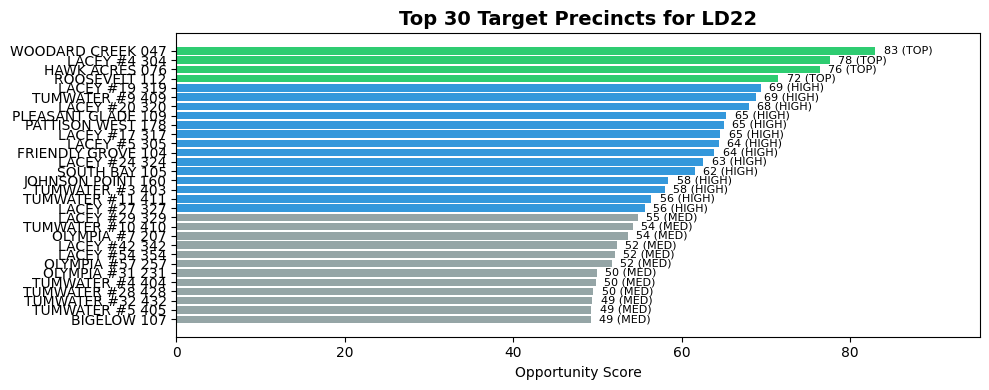


Top 30 precincts: 18,448 total ballots
Avg Doglio change: +2.3 pts (negative = opportunity)


In [22]:
# Top 5 Opportunity Precincts - Chart for Report
top5 = candidate_view.head(30).copy()

fig, ax = plt.subplots(figsize=(10, 4))

colors = ['#2ecc71' if t == 'TIER 1 - TOP' else '#3498db' if t == 'TIER 2 - HIGH' else '#95a5a6' 
          for t in top5['Tier']]

bars = ax.barh(top5['Precinct'], top5['Opportunity Score'], color=colors)
ax.invert_yaxis()
ax.set_xlabel('Opportunity Score')
ax.set_title('Top 30 Target Precincts for LD22', fontsize=14, fontweight='bold')
ax.set_xlim(0, max(top5['Opportunity Score']) * 1.15)

# Add score labels on bars
for bar, score, tier in zip(bars, top5['Opportunity Score'], top5['Tier']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{score:.0f} ({tier.split(" - ")[1]})', 
            va='center', fontsize=8)

plt.tight_layout()
plt.show()

# Quick summary stats
print(f"\nTop 30 precincts: {top5['Ballots (2024)'].sum():,.0f} total ballots")
print(f"Avg Doglio change: {top5['Doglio change (pts)'].mean():+.1f} pts (negative = opportunity)")

In [23]:
# Export ALL columns to CSV with proper encoding
candidate_view.to_csv('ld22_opportunity_rankings.csv', index=False, encoding='utf-8-sig')

print(f"Exported: ld22_opportunity_rankings.csv ({len(candidate_view)} precincts)")
print(f"\nColumns exported: {list(candidate_view.columns)}")
print(f"\nTier summary:")
print(candidate_view['Tier'].value_counts().sort_index().to_string())

Exported: ld22_opportunity_rankings.csv (147 precincts)

Columns exported: ['Precinct', 'Ballots (2024)', 'Turnout % (2024)', 'Pos 1 winner share (2024)', 'Pos 1 margin (2024 pts)', 'Pos 1 closeness band', 'Pos 2 winner share (2024)', 'Pos 2 margin (2024 pts)', 'Pos 2 closeness band', 'Doglio share 2022 (Pos 1)', 'Doglio share 2024 (Pos 1)', 'Doglio change (pts)', 'Doglio change band', 'Opportunity Score', 'Tier']

Tier summary:
Tier
TIER 1 - TOP      4
TIER 2 - HIGH    14
TIER 3 - MED     38
TIER 4 - LOW     91
